In [1]:
import torch 
import pandas as pd 
import numpy as np
import os
from matplotlib import pyplot as plt
from gsnn.interpret.utils import plot_edge_importance
from lincs_gsnn.explain.topology import adjust_for_topology
from lincs_gsnn.explain.utils import generate_masked_trajectories

%load_ext autoreload
%autoreload 2


# NON-CONTRASTIVE: Palbociclib and CCNA2 

target_gene: 'CCNA2'  

TODO: can we prioritize MTOR/PI3K pathway as the escape mechanism? 


In [2]:
EXP_NAME = 'palbociclib_ccna2'
ROOT_NAME = 'exp_14'

root = f'/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-gsnn/{ROOT_NAME}'
save_dir = f'/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-gsnn/{ROOT_NAME}/notebook_{EXP_NAME}/'
os.makedirs(save_dir, exist_ok=True)

data = torch.load(os.path.join(root, 'bionetwork/bionetwork.pt'), weights_only=False)

TARGET_GENE = 'CCNA2'
CELL_LINE_1 = 'T47D'
DRUG_ID = 'BRD-K51313569'
INCLUSION_THRESHOLD = 0.5 

# Load and aggregated explanations 

In [3]:
from lincs_gsnn.explain.eval import agg_node_scores

path = f'{root}/non_contrastive_explanation_{EXP_NAME}_node_target__{CELL_LINE_1.replace("-", "")}/aggregated_cres.csv'
node_df = agg_node_scores(path, fill_value=np.nan)
node_df.head() 

,node,mean_gsnn_score,mean_ig_score,mean_oc_score
0,COMPLEX__ACTA1_ACTL6A_ALKBH3_BRD2_BRD8_DMAP1_E...,0.003648,0.0,0.0
1,COMPLEX__ACTL6A_ACTL6B_ARID1A_ARID1B_ARID2_PBR...,0.003577,0.0,0.0
2,COMPLEX__AKT1S1_DEPTOR_MLST8_MTOR_RPTOR,0.003483,0.0,0.0
3,COMPLEX__APC_AXIN1_GSK3B,0.003033,0.0,0.0
4,COMPLEX__APC_CDC20,0.003328,0.0,0.0


In [4]:
from lincs_gsnn.explain.eval import agg_edge_scores

path = f'{root}/non_contrastive_explanation_{EXP_NAME}__{CELL_LINE_1.replace("-", "")}/aggregated_cres.csv'
edge_df = agg_edge_scores(path, fill_value=np.nan)
edge_df.head() 

,source,target,mean_gsnn_score,std_gsnn_score,mean_ig_score,std_ig_score,mean_oc_score,std_oc_score,abs_ig_score,abs_oc_score
0,COMPLEX__ACTA1_ACTL6A_ALKBH3_BRD2_BRD8_DMAP1_E...,COMPLEX__ACTA1_ACTL6A_ALKBH3_BRD2_BRD8_DMAP1_E...,0.003261,0.000109,0.0,0.0,0.0,0.0,0.0,0.0
1,COMPLEX__ACTA1_ACTL6A_ALKBH3_BRD2_BRD8_DMAP1_E...,PROTEIN__H4C6,0.003251,0.000506,0.0,0.0,0.0,0.0,0.0,0.0
2,COMPLEX__ACTL6A_ACTL6B_ARID1A_ARID1B_ARID2_PBR...,COMPLEX__ACTL6A_ACTL6B_ARID1A_ARID1B_ARID2_PBR...,0.002467,0.000036,0.0,0.0,0.0,0.0,0.0,0.0
3,COMPLEX__ACTL6A_ACTL6B_ARID1A_ARID1B_ARID2_PBR...,PROTEIN__TP53,0.002574,0.000002,0.0,0.0,0.0,0.0,0.0,0.0
4,COMPLEX__AKT1S1_DEPTOR_MLST8_MTOR_RPTOR,COMPLEX__AKT1S1_DEPTOR_MLST8_MTOR_RPTOR,0.003238,0.000133,0.0,0.0,0.0,0.0,0.0,0.0


# Regulator Contributions 

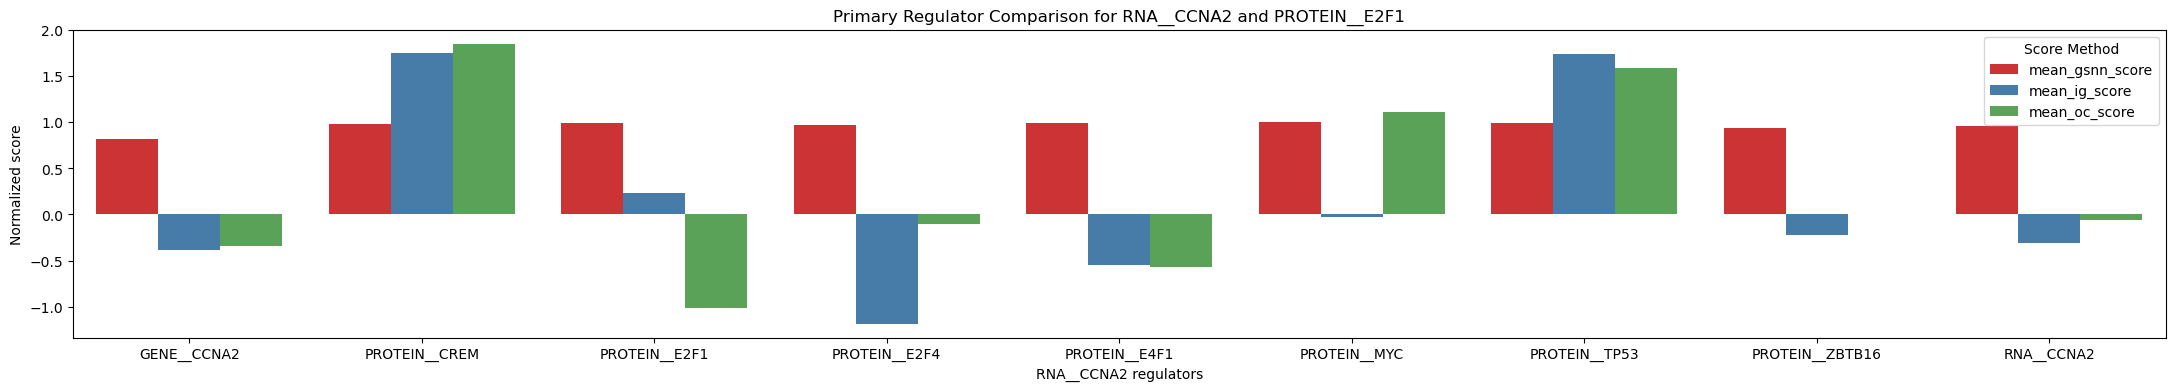

{'gsnn_rank': 3,
 'ig_rank': 7,
 'oc_rank': 1,
 'num_regulators': 9,
 'target_node': 'RNA__CCNA2',
 'expected_regulator': 'PROTEIN__E2F1',
 'expected_direction': 'negative'}

In [5]:
from lincs_gsnn.explain.eval import primary_regulator_comparison

reg_dict = primary_regulator_comparison(edge_df=edge_df, 
                                        target_node=f'RNA__{TARGET_GENE}', 
                                        expected_regulator='PROTEIN__E2F1', 
                                        expected_direction='negative', 
                                        plot=True, 
                                        save_dir=None)

reg_dict

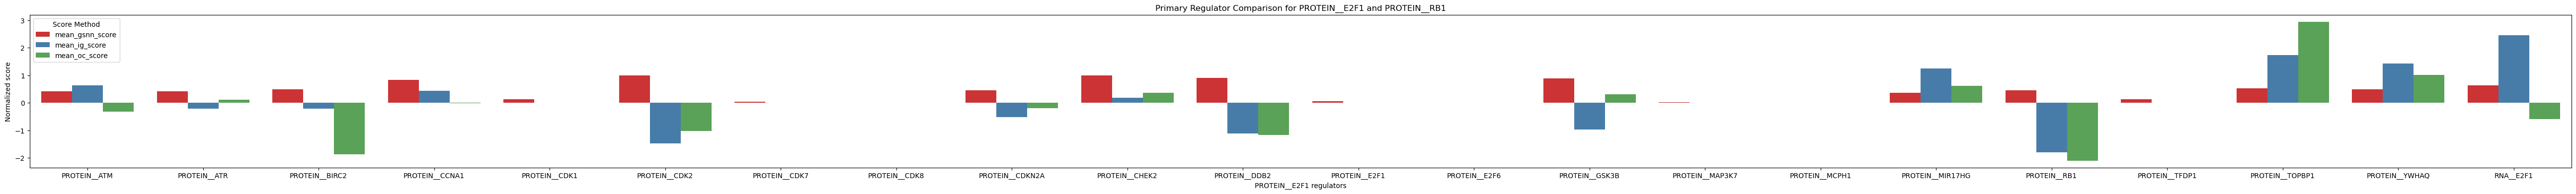

{'gsnn_rank': 11,
 'ig_rank': 1,
 'oc_rank': 1,
 'num_regulators': 22,
 'target_node': 'PROTEIN__E2F1',
 'expected_regulator': 'PROTEIN__RB1',
 'expected_direction': 'negative'}

In [6]:
reg_dict = primary_regulator_comparison(edge_df=edge_df, 
                                        target_node=f'PROTEIN__E2F1', 
                                        expected_regulator='PROTEIN__RB1', 
                                        expected_direction='negative', 
                                        plot=True, 
                                        save_dir=None)

reg_dict

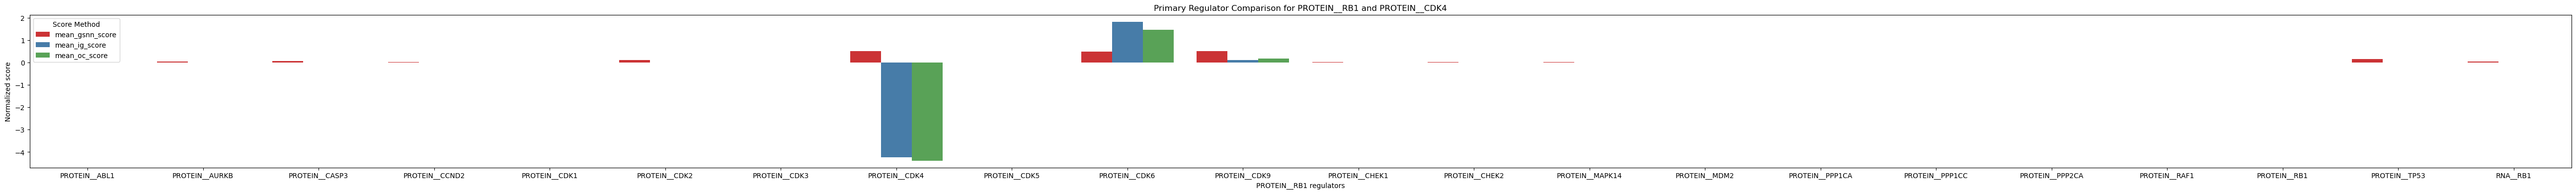

{'gsnn_rank': 1,
 'ig_rank': 1,
 'oc_rank': 1,
 'num_regulators': 22,
 'target_node': 'PROTEIN__RB1',
 'expected_regulator': 'PROTEIN__CDK4',
 'expected_direction': 'negative'}

In [7]:
reg_dict = primary_regulator_comparison(edge_df=edge_df, 
                                        target_node=f'PROTEIN__RB1', 
                                        expected_regulator='PROTEIN__CDK4', 
                                        expected_direction='negative', 
                                        plot=True, 
                                        save_dir=None)

reg_dict

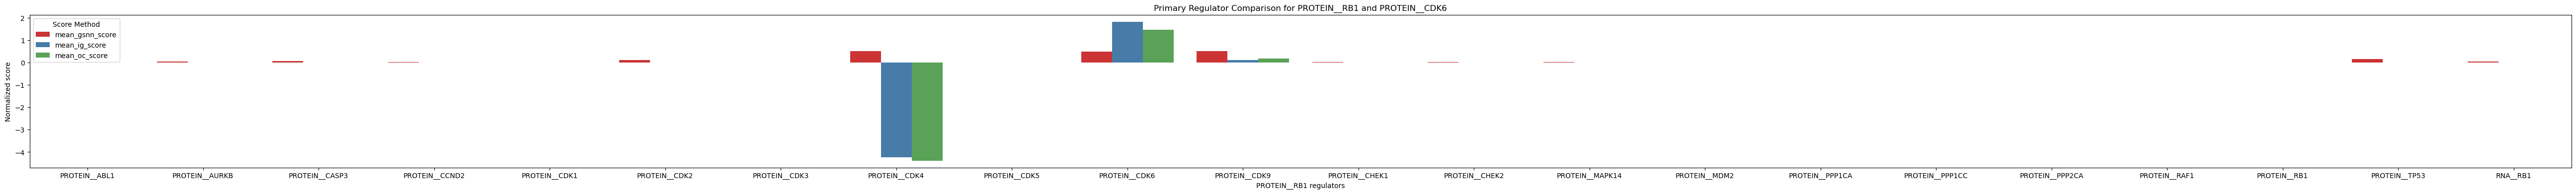

{'gsnn_rank': 3,
 'ig_rank': 22,
 'oc_rank': 22,
 'num_regulators': 22,
 'target_node': 'PROTEIN__RB1',
 'expected_regulator': 'PROTEIN__CDK6',
 'expected_direction': 'negative'}

In [8]:
reg_dict = primary_regulator_comparison(edge_df=edge_df, 
                                        target_node=f'PROTEIN__RB1', 
                                        expected_regulator='PROTEIN__CDK6', 
                                        expected_direction='negative', 
                                        plot=True, 
                                        save_dir=None)

reg_dict

# Node ranking comparison 

In [9]:
from lincs_gsnn.explain.eval import data2nx, node_ranking_comparison

G = data2nx(data)

INVOLVED_NODES = ['DRUG__BRD-K51313569', 'PROTEIN__CDK4', 'PROTEIN__CDK6', 'PROTEIN__RB1', 'PROTEIN__E2F1', 'RNA__CCNA2', 'GENE__CCNA2']

mrr_node, node_rank_df = node_ranking_comparison(node_df=node_df, 
                                            G=G, 
                                            target_node=f'RNA__{TARGET_GENE}', 
                                            source_node=f'DRUG__{DRUG_ID}', 
                                            expected_nodes=INVOLVED_NODES, 
                                            expected_direction='negative')


generating random walk baseline...
generating pagerank baseline...
generating rw-betweenness baseline...
generating betweenness centrality baseline...


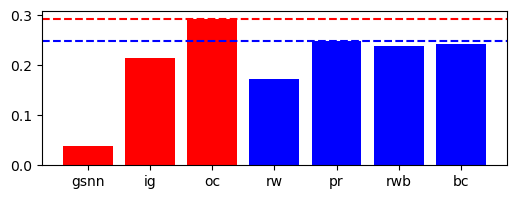

In [10]:
plt.figure(figsize=(6, 2)) 
plt.bar(mrr_node.columns, mrr_node.values[0], color=['r','r','r', 'b', 'b', 'b', 'b']) 
plt.axhline(mrr_node[['gsnn', 'ig', 'oc']].values.ravel().max(), color='r', linestyle='--')
plt.axhline(mrr_node[['rw', 'pr', 'rwb', 'bc']].values.ravel().max(), color='b', linestyle='--')
plt.show() 


# Edge ranking comparison 

In [11]:
from lincs_gsnn.explain.eval import edge_ranking_comparison

EXPECTED_EDGES = pd.DataFrame({'source': ['DRUG__BRD-K51313569', 'DRUG__BRD-K51313569', 'PROTEIN__CDK4', 'PROTEIN__CDK6', 'PROTEIN__RB1', 'PROTEIN__E2F1'], 
                               'target': ['PROTEIN__CDK6', 'PROTEIN__CDK4', 'PROTEIN__RB1', 'PROTEIN__RB1', 'PROTEIN__E2F1', 'RNA__CCNA2']})

mrr_edge, edge_rank_df = edge_ranking_comparison(edge_df=edge_df, 
                                                G=G, 
                                                source_node=f'DRUG__{DRUG_ID}', 
                                                target_node=f'GENE__{TARGET_GENE}', 
                                                expected_edges=EXPECTED_EDGES)

edge_rank_df 

generating random walk baseline...
generating pagerank baseline...
generating rw-betweenness baseline...
generating betweenness centrality baseline...


source,target,gsnn_rank,ig_rank,oc_rank,rw_rank,pr_rank,rwb_rank,bc_rank
DRUG__BRD-K51313569,PROTEIN__CDK4,2,30,16,7,6,6,3
DRUG__BRD-K51313569,PROTEIN__CDK6,3,62,26627,8,8,5,3
PROTEIN__CDK4,PROTEIN__RB1,102,14,9,37,35,42,20
PROTEIN__CDK6,PROTEIN__RB1,148,26697,26695,30,25,29,20
PROTEIN__E2F1,RNA__CCNA2,16,26699,10,52,46,14,9
PROTEIN__RB1,PROTEIN__E2F1,206,12,8,13,14,22,9


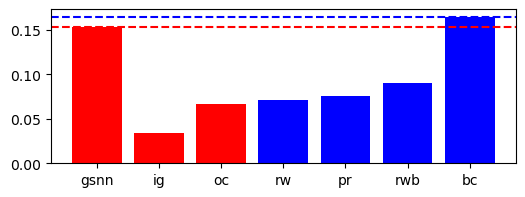

In [12]:
plt.figure(figsize=(6, 2)) 
plt.bar(mrr_edge.columns, mrr_edge.values[0], color=['r','r','r', 'b', 'b', 'b', 'b']) 
plt.axhline(mrr_edge[['gsnn', 'ig', 'oc']].values.ravel().max(), color='r', linestyle='--')
plt.axhline(mrr_edge[['rw', 'pr', 'rwb', 'bc']].values.ravel().max(), color='b', linestyle='--')
plt.show() 


## Path ranking comparison 

In [13]:
from lincs_gsnn.explain.eval import path_ranking_comparison

EXPECTED_PATHS = [
                  'CDK4 -> RB1 -> E2F1 -> CCNA2', 
                  'CDK6 -> RB1 -> E2F1 -> CCNA2',
                  ]

mrr_path, path_rank_df = path_ranking_comparison(path_df=edge_df, 
                                                G=G, 
                                                source_node=f'DRUG__{DRUG_ID}', 
                                                target_node=f'GENE__{TARGET_GENE}', 
                                                expected_paths=EXPECTED_PATHS, 
                                                expected_direction='negative', 
                                                max_path_length=6)

path_rank_df 

generating random walk baseline...
generating pagerank baseline...
generating rw-betweenness baseline...
generating betweenness centrality baseline...
adding edge attributes to G...
scoring paths (product) ...
scoring paths (sum) ...
scoring paths (mean) ...


,path_short,mean_gsnn_score_product_rank,mean_ig_score_sum_rank,mean_oc_score_sum_rank,rw_score_sum_rank,pr_score_sum_rank,rwb_score_sum_rank,bc_score_sum_rank
1,CDK4 -> RB1 -> E2F1 -> CCNA2,5.0,9.0,1.0,11.0,11.0,31.0,6.0
42,CDK6 -> RB1 -> E2F1 -> CCNA2,6.0,32.0,8.0,32.0,31.0,40.0,6.0


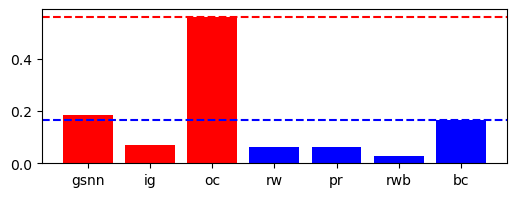

In [14]:
mrr_path = mrr_path.rename(columns={'mean_gsnn_score_product': 'gsnn', 
                                    'mean_ig_score_sum': 'ig', 
                                    'mean_oc_score_sum': 'oc', 
                                    'rw_score_sum': 'rw', 
                                    'pr_score_sum': 'pr', 
                                    'rwb_score_sum': 'rwb', 
                                    'bc_score_sum': 'bc'})
plt.figure(figsize=(6, 2)) 
plt.bar(mrr_path.columns, mrr_path.values[0], color=['r','r','r', 'b', 'b', 'b', 'b']) 
plt.axhline(mrr_path[['gsnn', 'ig', 'oc']].values.ravel().max(), color='r', linestyle='--')
plt.axhline(mrr_path[['rw', 'pr', 'rwb', 'bc']].values.ravel().max(), color='b', linestyle='--')
plt.show() 


---
# Subgraph Explanation Plot 
---

In [15]:
FILTER_TO_DRUG = False
TARGET_NAME = f'RNA__{TARGET_GENE}'
DRUG_NAME = f'DRUG__{DRUG_ID}'

TOP_N_NODES = 100
REMOVE_CELL___EDGES = True
REMOVE_GENE___EDGES = True
PROB_FILTER_THRESH = 0.0

CLIP_SCORE = True
CLIP_VALUE = 10

SCALE_SCORE = True
MIN_SCORE = -1
MAX_SCORE = 1

FILTER_BY_SCORE = 'mean_gsnn_score'
COLOR_BY_SCORE = 'mean_ig_score' # options: 'mean_ig_score', 'mean_oc_score', 'mean_gsnn_score'\

FIGSIZE = (13,11)
INTERACTIVE = False

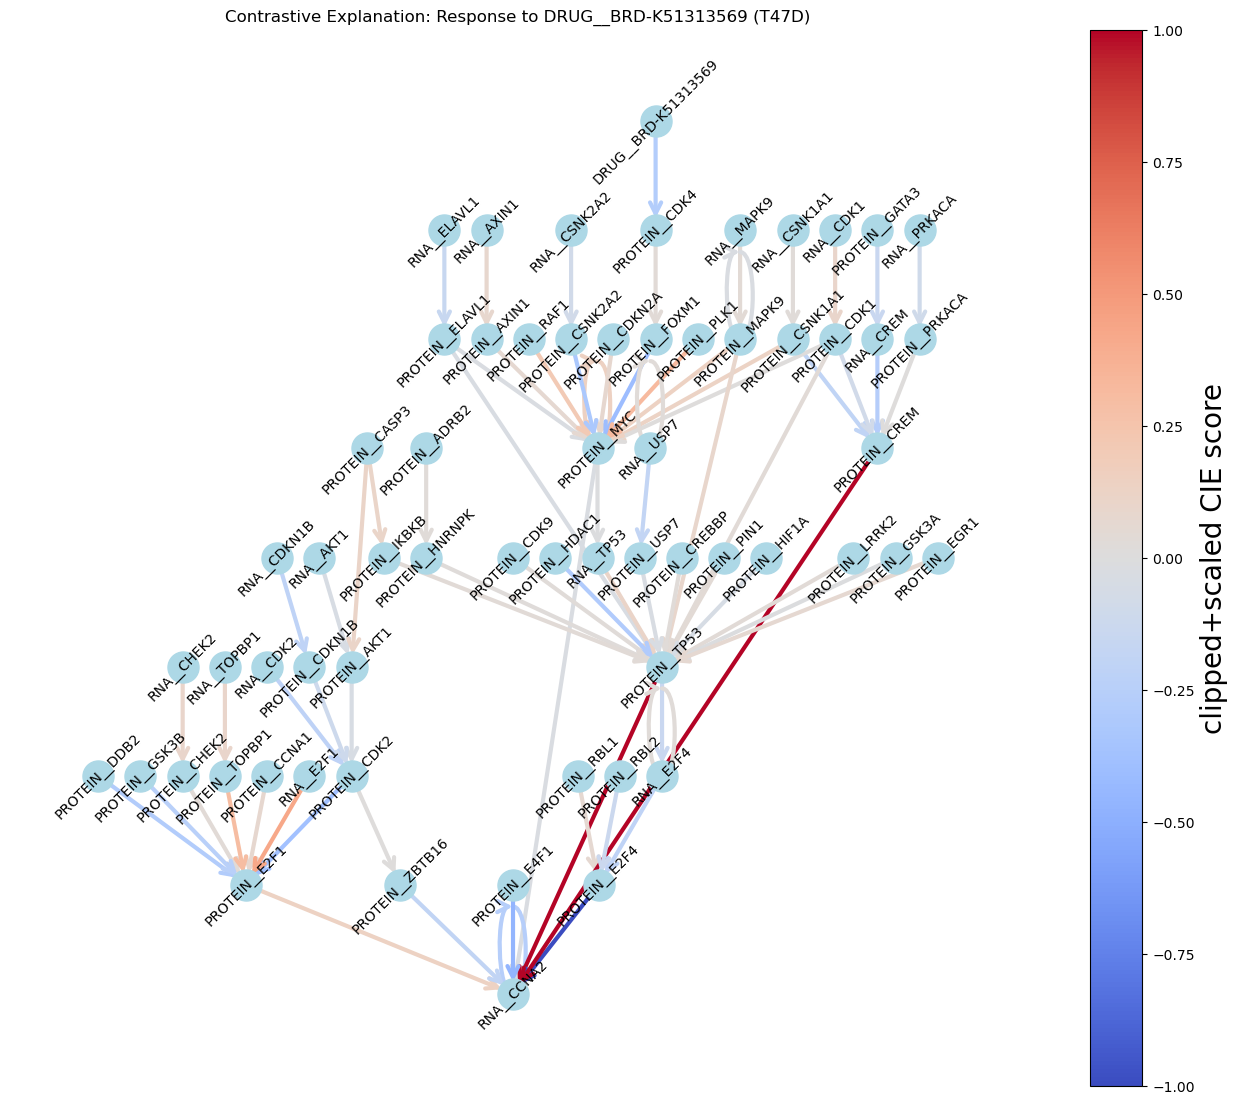

In [16]:
ccres = edge_df.assign(**{'score': lambda x: x[COLOR_BY_SCORE],
                                        'abs_ig_score': lambda x: np.abs(x.mean_ig_score),
                                        'abs_oc_score': lambda x: np.abs(x.mean_oc_score)})[['source', 'target', 'score', FILTER_BY_SCORE]]

if REMOVE_CELL___EDGES: 
    ccres = ccres[lambda x: ~(x.source.str.contains('LINE__') | x.target.str.contains('LINE__'))]

if REMOVE_GENE___EDGES: 
    ccres = ccres[lambda x: ~(x.source.str.contains('GENE__') | x.target.str.contains('GENE__'))]

ccres = ccres[ccres[FILTER_BY_SCORE] > PROB_FILTER_THRESH]

ccres = ccres.sort_values(by=FILTER_BY_SCORE, ascending=False).head(TOP_N_NODES)

# SCALING FOR COLOR DISPLAY
if CLIP_SCORE: 
    ccres = ccres.assign(score = lambda x: x.score.values.clip(-CLIP_VALUE, CLIP_VALUE))

if SCALE_SCORE:
    # Scale by absolute max so 0 stays at 0 and signs are preserved
    abs_max = ccres.score.abs().max()
    ccres.loc[ccres.score < 0, 'score'] = ccres.loc[ccres.score < 0, 'score'] / np.abs(ccres.loc[ccres.score < 0, 'score'].min())
    ccres.loc[ccres.score > 0, 'score'] = ccres.loc[ccres.score > 0, 'score'] / np.abs(ccres.loc[ccres.score > 0, 'score'].max())

if INTERACTIVE: 
    figsize = (10, 10)
else: 
    figsize = FIGSIZE

plot_edge_importance(ccres, 
                     figsize=figsize, 
                     leafs=[TARGET_NAME], 
                     roots=[DRUG_NAME] if FILTER_TO_DRUG else None,
                     title=f'Contrastive Explanation: Response to {DRUG_NAME} ({CELL_LINE_1})',
                     interactive=INTERACTIVE, 
                     save=f'{save_dir}/explanation_subgraph_plot_non_interactive_{EXP_NAME}.png',
                     dpi=300, 
                     colorbar_label='clipped+scaled CIE score')



# Resistance pathways 

PI3K, MTOR 

In [17]:
[x.split('__')[1] for x in node_df.sort_values(by='mean_ig_score', ascending=False).head(25).node.values]

['TOPBP1',
 'MYC',
 'PIN1',
 'RPS6KA3',
 'CASP3',
 'PAK2',
 'TOPBP1',
 'MAPK3',
 'MYBL2',
 'ESR1',
 'MEN1',
 'ATR',
 'TP53',
 'BRD4',
 'RAF1',
 'CDKN2A',
 'AXIN1',
 'CLK2',
 'PAK1',
 'IKBKB',
 'AR',
 'PRKACA',
 'RBL2',
 'RARA',
 'ELK1']

In [18]:
node_df.sort_values(by='mean_ig_score', ascending=False).head(10)

,node,mean_gsnn_score,mean_ig_score,mean_oc_score
3077,PROTEIN__TOPBP1,0.497476,0.144003,0.299143
4315,RNA__MYC,0.319068,0.140836,0.288747
4533,RNA__PIN1,0.267033,0.114985,0.212567
2831,PROTEIN__RPS6KA3,0.680828,0.112078,0.069527
1545,PROTEIN__CASP3,0.499331,0.107322,0.341889
2527,PROTEIN__PAK2,0.494391,0.106808,0.264218
5054,RNA__TOPBP1,0.485171,0.102134,0.377936
2306,PROTEIN__MAPK3,0.486968,0.093821,0.201036
2383,PROTEIN__MYBL2,0.422995,0.081271,0.151350
1866,PROTEIN__ESR1,0.963930,0.077293,0.190231


In [19]:
node_df.sort_values(by='mean_oc_score', ascending=False).head(10)

,node,mean_gsnn_score,mean_ig_score,mean_oc_score
1509,PROTEIN__BRD4,0.447829,0.068733,0.621489
3415,RNA__CASP3,0.426441,0.002742,0.411700
5054,RNA__TOPBP1,0.485171,0.102134,0.377936
1545,PROTEIN__CASP3,0.499331,0.107322,0.341889
3077,PROTEIN__TOPBP1,0.497476,0.144003,0.299143
4315,RNA__MYC,0.319068,0.140836,0.288747
2527,PROTEIN__PAK2,0.494391,0.106808,0.264218
3079,PROTEIN__TP53,0.987680,-0.091428,0.246703
4533,RNA__PIN1,0.267033,0.114985,0.212567
2306,PROTEIN__MAPK3,0.486968,0.093821,0.201036


# Masking impact on trajectories 

[PROTEIN__E2F1] - sample 0
[PROTEIN__E2F4] - sample 0
[PROTEIN__MYC] - sample 0
[PROTEIN__TP53] - sample 0
[PROTEIN__RB1] - sample 0


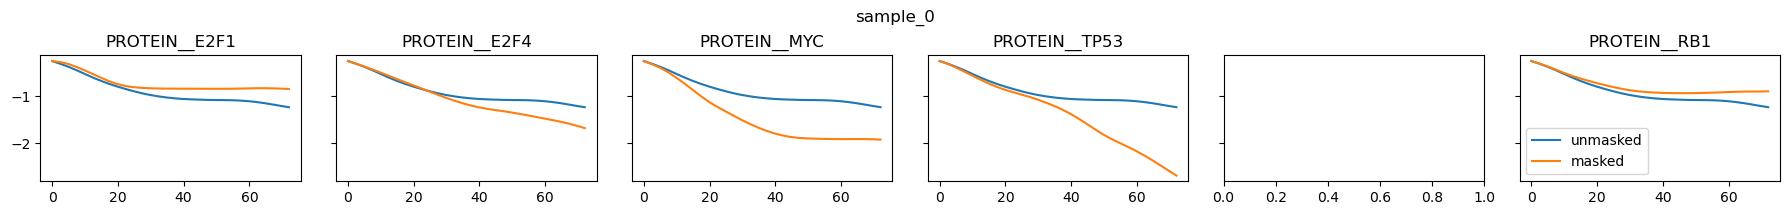

In [20]:
sample_ids = [0] 
root_gsnn = root 
root_traj = '/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-traj/runs/exp/default_v03/output/'

# Given a condition (set of dxdt obs within a condition), what edges are necessary to maintain the predicted values?

drug = DRUG_ID
dose = 10.0

genes_to_remove = ['PROTEIN__E2F1', 'PROTEIN__E2F4', 'PROTEIN__MYC', 'PROTEIN__TP53', 'RNA__hsa-miR-130b-3p', 'PROTEIN__RB1']

target_gene = f'GENE__{TARGET_GENE}'

t = torch.linspace(0, 72, 30) # num integration steps 

################################################################################################################
################################################################################################################


res_all ={} 
for remove_name in genes_to_remove: 
    if remove_name not in data.node_names_dict['function']: 
        continue 
    res_masked = {}
    for sample_ix in sample_ids:
        print(f'[{remove_name}] - sample {sample_ix}', end='\r')
        sample_id = f'sample_{sample_ix}'
        x1_t_hat, x1_t_hat_nm = generate_masked_trajectories(root_gsnn, root_traj, sample_id=sample_id, target_gene=target_gene, remove_name=remove_name, cell=CELL_LINE_1.replace('-', ''), drug=drug, dose=dose, t=t, method='dopri5', tol=1e-3)
        res_masked[sample_id] = {f'{CELL_LINE_1}_masked_{remove_name}': x1_t_hat_nm, 
                                f'{CELL_LINE_1}_all': x1_t_hat}

    res_all[remove_name] = res_masked 
    print() 


################################################################################################################
################################################################################################################

for sample_ix in sample_ids: 
    sample_id_ = f'sample_{sample_ix}'
    f,axes = plt.subplots(1, len(genes_to_remove), figsize=(3*len(genes_to_remove), 2), sharey=True)
    for jj, (ax, remove_name) in enumerate(zip(axes, genes_to_remove)): 
        if remove_name not in data.node_names_dict['function']: 
            continue 
        ax.plot(t, res_all[remove_name][sample_id_][f'{CELL_LINE_1}_all'], label='unmasked')
        ax.plot(t, res_all[remove_name][sample_id_][f'{CELL_LINE_1}_masked_{remove_name}'], label='masked')
        ax.set_title(remove_name)
    ax.legend()
    plt.tight_layout()
    plt.suptitle(f'{sample_id_}', y=1.05)
    plt.show() 


[PROTEIN__E2F1] - sample 0
[PROTEIN__E2F4] - sample 0
[PROTEIN__MYC] - sample 0
[PROTEIN__TP53] - sample 0
[PROTEIN__RB1] - sample 0


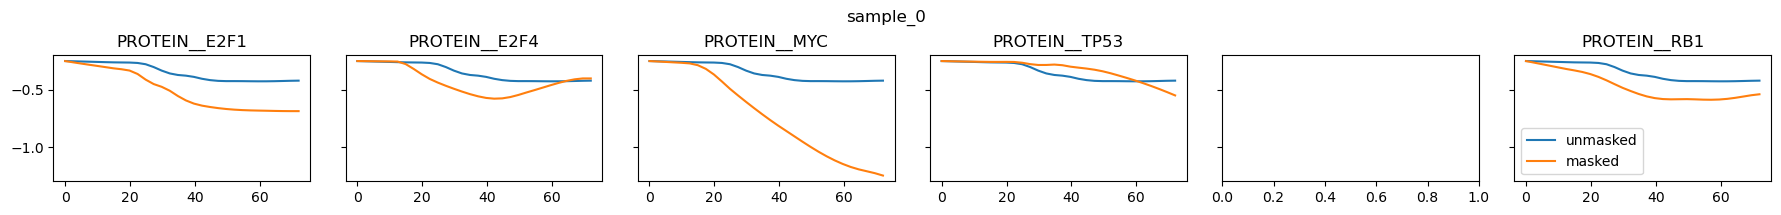

In [21]:
dose = 0.0

################################################################################################################
################################################################################################################


res_all ={} 
for remove_name in genes_to_remove: 
    if remove_name not in data.node_names_dict['function']: 
        continue 
    res_masked = {}
    for sample_ix in sample_ids:
        print(f'[{remove_name}] - sample {sample_ix}', end='\r')
        sample_id = f'sample_{sample_ix}'
        x1_t_hat, x1_t_hat_nm = generate_masked_trajectories(root_gsnn, root_traj, sample_id=sample_id, target_gene=target_gene, remove_name=remove_name, cell=CELL_LINE_1.replace('-', ''), drug=drug, dose=dose, t=t, method='dopri5', tol=1e-3)
        res_masked[sample_id] = {f'{CELL_LINE_1}_masked_{remove_name}': x1_t_hat_nm, 
                                f'{CELL_LINE_1}_all': x1_t_hat}

    res_all[remove_name] = res_masked 
    print() 


################################################################################################################
################################################################################################################

for sample_ix in sample_ids: 
    sample_id_ = f'sample_{sample_ix}'
    f,axes = plt.subplots(1, len(genes_to_remove), figsize=(3*len(genes_to_remove), 2), sharey=True)
    for jj, (ax, remove_name) in enumerate(zip(axes, genes_to_remove)): 
        if remove_name not in data.node_names_dict['function']: 
            continue 
        ax.plot(t, res_all[remove_name][sample_id_][f'{CELL_LINE_1}_all'], label='unmasked')
        ax.plot(t, res_all[remove_name][sample_id_][f'{CELL_LINE_1}_masked_{remove_name}'], label='masked')
        ax.set_title(remove_name)
    ax.legend()
    plt.tight_layout()
    plt.suptitle(f'{sample_id_}', y=1.05)
    plt.show() 
